# Hospital Operations Analysis

---
## Sources & links 

Kaggle Dataset : [Hospital Management Dataset](https://www.kaggle.com/datasets/kanakbaghel/hospital-management-dataset?select=appointments.csv)

Website used to create ERD : [dbdiagram.io](https://dbdiagram.io/home)

---
## Overview 
- title 
- sources & links
- overview
- figures
- imports
    - library imports
    - data imports
- business understanding 
    - business objectives 
    - situation assesment 
    - project plan
- data understanding
    - data properties 
    - ERD
- methodology
- functions
- database management
    - clear old database 
    - create database connection
    - create tables
    - data insertion & validation
- business questions & analysis
    - executive performance
    - branch performace 
    - operations
    - financial performance 
    - patient demographics 

--- 
## Figures

- Figure 1. Entity Relationship Diagram (ERD) of the hospital operations database.
- Figure 2. Monthly revenue for the calandar year of 2023.
- Figure 3. Revenue per branch.
- Figure 4. Average Revenue Per Patient
- Figure 5. Monthly Revenue by Hospital Branch
- Figure 6. Branch Appointment Volume
- Figure 7. Scheduled Appointments by Doctor
- Figure 8. Completed Appointments by Doctor
- Figure 9. Total amount of each treatment
- Figure 10. Total Revenue Per Patient
- Figure 11. Cost Per Treatment
- Figure 12. Revenue Per Branch
- Figure 13. Revenue By Insurance

---
## Imports

### Library Imports

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

In [2]:
# this cell is to show the last update to this notebook
now = datetime.now()
print(f'This notebook was last updated at : {now} PST')

This notebook was last updated at : 2026-07-30 11:50:30.047012 PST


### Data Imports 

In [3]:
patients_df = pd.read_csv('operations_data/patients.csv')
doctors_df = pd.read_csv('operations_data/doctors.csv')
appointments_df = pd.read_csv('operations_data/appointments.csv')
billing_df = pd.read_csv('operations_data/billing.csv')
treatment_df = pd.read_csv('operations_data/treatments.csv')

In [4]:
patients_df.head()

,patient_id,first_name,last_name,gender,date_of_birth,contact_number,address,registration_date,insurance_provider,insurance_number,email
0,P001,David,Williams,F,1955-06-04,6939585183,789 Pine Rd,2022-06-23,WellnessCorp,INS840674,david.williams@mail.com
1,P002,Emily,Smith,F,1984-10-12,8228188767,321 Maple Dr,2022-01-15,PulseSecure,INS354079,emily.smith@mail.com
2,P003,Laura,Jones,M,1977-08-21,8397029847,321 Maple Dr,2022-02-07,PulseSecure,INS650929,laura.jones@mail.com
3,P004,Michael,Johnson,F,1981-02-20,9019443432,123 Elm St,2021-03-02,HealthIndia,INS789944,michael.johnson@mail.com
4,P005,David,Wilson,M,1960-06-23,7734463155,123 Elm St,2021-09-29,MedCare Plus,INS788105,david.wilson@mail.com


In [5]:
doctors_df.head()

,doctor_id,first_name,last_name,specialization,phone_number,years_experience,hospital_branch,email
0,D001,David,Taylor,Dermatology,8322010158,17,Westside Clinic,dr.david.taylor@hospital.com
1,D002,Jane,Davis,Pediatrics,9004382050,24,Eastside Clinic,dr.jane.davis@hospital.com
2,D003,Jane,Smith,Pediatrics,8737740598,19,Eastside Clinic,dr.jane.smith@hospital.com
3,D004,David,Jones,Pediatrics,6594221991,28,Central Hospital,dr.david.jones@hospital.com
4,D005,Sarah,Taylor,Dermatology,9118538547,26,Central Hospital,dr.sarah.taylor@hospital.com


In [6]:
appointments_df.head()

,appointment_id,patient_id,doctor_id,appointment_date,appointment_time,reason_for_visit,status
0,A001,P034,D009,2023-08-09,15:15:00,Therapy,Scheduled
1,A002,P032,D004,2023-06-09,14:30:00,Therapy,No-show
2,A003,P048,D004,2023-06-28,8:00:00,Consultation,Cancelled
3,A004,P025,D006,2023-09-01,9:15:00,Consultation,Cancelled
4,A005,P040,D003,2023-07-06,12:45:00,Emergency,No-show


In [7]:
billing_df.head()

,bill_id,patient_id,treatment_id,bill_date,amount,payment_method,payment_status
0,B001,P034,T001,2023-08-09,3941.97,Insurance,Pending
1,B002,P032,T002,2023-06-09,4158.44,Insurance,Paid
2,B003,P048,T003,2023-06-28,3731.55,Insurance,Paid
3,B004,P025,T004,2023-09-01,4799.86,Insurance,Failed
4,B005,P040,T005,2023-07-06,582.05,Credit Card,Pending


In [8]:
treatment_df.head()

,treatment_id,appointment_id,treatment_type,description,cost,treatment_date
0,T001,A001,Chemotherapy,Basic screening,3941.97,2023-08-09
1,T002,A002,MRI,Advanced protocol,4158.44,2023-06-09
2,T003,A003,MRI,Standard procedure,3731.55,2023-06-28
3,T004,A004,MRI,Basic screening,4799.86,2023-09-01
4,T005,A005,ECG,Standard procedure,582.05,2023-07-06


---
## Business Understanding 

---
## Data Understanding

### Data Properties

### ERD 

This hospital database consists of five normalized tables that model the relationships between patients, doctors, appointments, treatments, and billing records. As shown in Figure 1, an ERD illustrates the database structure and foreign key relationships.

>Figure 1. Entity Relationship Diagram (ERD) of the hospital operations database.

<img src="assets/hospital_erd.png" width="700">

---
## Methodology

---
## Functions

---
## Database Management 
Here we are firstly going to clear this notebooks database, as this prevents data being du

In [9]:
# delete old database
db_path = Path('hospital.db')

if db_path.exists():
    db_path.unlink()

Then create an empty database for us to add tables and eventually populate those tables with the data from the `.csv` file. This is done this way so we can have much more control over the database. 

In [10]:
conn = sqlite3.connect('hospital.db')
conn.execute('PRAGMA foreign_keys = ON')

### Tables
Here we create empty tables with the constraints we want for each data point. We will also be creating smaller dataframes for each table to pull data from so we can only use the data from each table we want. 

In [11]:
# patients table
conn.execute("""
CREATE TABLE patients (
patient_id TEXT PRIMARY KEY,
first_name TEXT,
last_name TEXT,
gender TEXT,
date_of_birth TEXT,
insurance_provider TEXT
);
""")

In [12]:
patients_sql = patients_df[['patient_id', 'first_name', 'last_name', 'gender', 'date_of_birth', 'insurance_provider']]

In [13]:
patients_sql.head()

,patient_id,first_name,last_name,gender,date_of_birth,insurance_provider
0,P001,David,Williams,F,1955-06-04,WellnessCorp
1,P002,Emily,Smith,F,1984-10-12,PulseSecure
2,P003,Laura,Jones,M,1977-08-21,PulseSecure
3,P004,Michael,Johnson,F,1981-02-20,HealthIndia
4,P005,David,Wilson,M,1960-06-23,MedCare Plus


In [14]:
# doctors table
conn.execute("""
CREATE TABLE doctors (
doctor_id TEXT PRIMARY KEY,
first_name TEXT,
last_name TEXT,
specialization TEXT,
hospital_branch TEXT
);
""")

In [15]:
doctors_sql = doctors_df [['doctor_id', 'first_name', 'last_name', 'specialization', 'hospital_branch']]

In [16]:
doctors_sql.head()

,doctor_id,first_name,last_name,specialization,hospital_branch
0,D001,David,Taylor,Dermatology,Westside Clinic
1,D002,Jane,Davis,Pediatrics,Eastside Clinic
2,D003,Jane,Smith,Pediatrics,Eastside Clinic
3,D004,David,Jones,Pediatrics,Central Hospital
4,D005,Sarah,Taylor,Dermatology,Central Hospital


In [17]:
# appointmets table
conn.execute("""
CREATE TABLE appointments (
appointment_id TEXT PRIMARY KEY,
patient_id TEXT,
doctor_id TEXT,
appointment_date TEXT,
status TEXT,
reason_for_visit TEXT,

FOREIGN KEY(patient_id)
    REFERENCES patients(patient_id),
FOREIGN KEY(doctor_id)
    REFERENCES doctors(doctor_id)
);
""")

In [18]:
appointments_sql = appointments_df [['appointment_id', 'patient_id', 'doctor_id', 'appointment_date', 'status', 'reason_for_visit']]

In [19]:
appointments_sql.head()

,appointment_id,patient_id,doctor_id,appointment_date,status,reason_for_visit
0,A001,P034,D009,2023-08-09,Scheduled,Therapy
1,A002,P032,D004,2023-06-09,No-show,Therapy
2,A003,P048,D004,2023-06-28,Cancelled,Consultation
3,A004,P025,D006,2023-09-01,Cancelled,Consultation
4,A005,P040,D003,2023-07-06,No-show,Emergency


In [20]:
# billing table
conn.execute("""
CREATE TABLE billing (
bill_id TEXT PRIMARY KEY,
patient_id TEXT,
treatment_id TEXT,
bill_date TEXT,
amount REAL,
payment_status TEXT,

FOREIGN KEY(patient_id)
    REFERENCES patients(patient_id),
FOREIGN KEY(treatment_id)
    REFERENCES treatments(treatment_id)
);
""")

In [21]:
billing_sql = billing_df[['bill_id', 'patient_id', 'treatment_id', 'bill_date', 'amount', 'payment_status']]

In [22]:
billing_sql.head()

,bill_id,patient_id,treatment_id,bill_date,amount,payment_status
0,B001,P034,T001,2023-08-09,3941.97,Pending
1,B002,P032,T002,2023-06-09,4158.44,Paid
2,B003,P048,T003,2023-06-28,3731.55,Paid
3,B004,P025,T004,2023-09-01,4799.86,Failed
4,B005,P040,T005,2023-07-06,582.05,Pending


In [23]:
# treatment table
conn.execute("""
CREATE TABLE treatments (
treatment_id TEXT PRIMARY KEY,
appointment_id TEXT NOT NULL,
treatment_type TEXT,
description TEXT,
cost real,
treatment_date TEXT,

FOREIGN KEY(appointment_id)
    REFERENCES appointments(appointment_id)
);
""")

In [24]:
treatment_sql = treatment_df[['treatment_id', 'appointment_id', 'treatment_type', 'description', 'cost', 'treatment_date']]

In [25]:
treatment_sql.head()

,treatment_id,appointment_id,treatment_type,description,cost,treatment_date
0,T001,A001,Chemotherapy,Basic screening,3941.97,2023-08-09
1,T002,A002,MRI,Advanced protocol,4158.44,2023-06-09
2,T003,A003,MRI,Standard procedure,3731.55,2023-06-28
3,T004,A004,MRI,Basic screening,4799.86,2023-09-01
4,T005,A005,ECG,Standard procedure,582.05,2023-07-06


### Data Insertion
Here we are populating our tables, then using the output below the insertion to validate it worked properly.

In [26]:
# patients table
patients_sql.to_sql(
    'patients',
    conn,
    if_exists = 'append',
    index = False
)

50

In [27]:
# validation
pd.read_sql("""
SELECT COUNT(*) as total_patients
FROM patients
""", conn)

,total_patients
0,50


In [28]:
pd.read_sql("""
SELECT *
FROM patients
LIMIT 5
""", conn)

,patient_id,first_name,last_name,gender,date_of_birth,insurance_provider
0,P001,David,Williams,F,1955-06-04,WellnessCorp
1,P002,Emily,Smith,F,1984-10-12,PulseSecure
2,P003,Laura,Jones,M,1977-08-21,PulseSecure
3,P004,Michael,Johnson,F,1981-02-20,HealthIndia
4,P005,David,Wilson,M,1960-06-23,MedCare Plus


In [29]:
# doctors table
doctors_sql.to_sql(
    'doctors',
    conn,
    if_exists = 'append',
    index = False
)

10

In [30]:
# validation
pd.read_sql("""
SELECT COUNT(*) as total_doctors
FROM doctors
""", conn)

,total_doctors
0,10


In [31]:
pd.read_sql("""
SELECT * 
FROM doctors
LIMIT 5
""", conn)

,doctor_id,first_name,last_name,specialization,hospital_branch
0,D001,David,Taylor,Dermatology,Westside Clinic
1,D002,Jane,Davis,Pediatrics,Eastside Clinic
2,D003,Jane,Smith,Pediatrics,Eastside Clinic
3,D004,David,Jones,Pediatrics,Central Hospital
4,D005,Sarah,Taylor,Dermatology,Central Hospital


In [32]:
# appointments table
appointments_sql.to_sql(
    'appointments',
    conn,
    if_exists = 'append',
    index = False
)

200

In [33]:
# validation
pd.read_sql("""
SELECT COUNT(*) as total_appointments
FROM appointments
""", conn)

,total_appointments
0,200


In [34]:
pd.read_sql("""
select *
FROM appointments
LIMIT 5
""", conn)

,appointment_id,patient_id,doctor_id,appointment_date,status,reason_for_visit
0,A001,P034,D009,2023-08-09,Scheduled,Therapy
1,A002,P032,D004,2023-06-09,No-show,Therapy
2,A003,P048,D004,2023-06-28,Cancelled,Consultation
3,A004,P025,D006,2023-09-01,Cancelled,Consultation
4,A005,P040,D003,2023-07-06,No-show,Emergency


In [35]:
# treatments table
treatment_sql.to_sql(
    'treatments',
    conn,
    if_exists = 'append', 
    index = False
)

200

In [36]:
# validation
pd.read_sql("""
select COUNT(*) as total_treatments
from treatments
""", conn)

,total_treatments
0,200


In [37]:
pd.read_sql("""
select *
from treatments
limit 5
""", conn)

,treatment_id,appointment_id,treatment_type,description,cost,treatment_date
0,T001,A001,Chemotherapy,Basic screening,3941.97,2023-08-09
1,T002,A002,MRI,Advanced protocol,4158.44,2023-06-09
2,T003,A003,MRI,Standard procedure,3731.55,2023-06-28
3,T004,A004,MRI,Basic screening,4799.86,2023-09-01
4,T005,A005,ECG,Standard procedure,582.05,2023-07-06


In [38]:
# billing table 
billing_sql.to_sql(
    'billing',
    conn,
    if_exists = 'append',
    index = False
)

200

In [39]:
# validation
pd.read_sql("""
select COUNT(*) as total_bills
from billing
""", conn)

,total_bills
0,200


In [40]:
pd.read_sql("""
select *
from billing
limit 5
""", conn)

,bill_id,patient_id,treatment_id,bill_date,amount,payment_status
0,B001,P034,T001,2023-08-09,3941.97,Pending
1,B002,P032,T002,2023-06-09,4158.44,Paid
2,B003,P048,T003,2023-06-28,3731.55,Paid
3,B004,P025,T004,2023-09-01,4799.86,Failed
4,B005,P040,T005,2023-07-06,582.05,Pending


In [41]:
conn.commit()

With the database successfully constructed and validated, the following analysis uses SQL and Python to answer key business questions regarding hospital performance.

---
## Business Questions & Analysis

### Executive Performance 
_Is the organization healthy_

The following analysis evaluates the overall operational and financial performance of the hospital network by examining key executive performance indicators.

In [42]:
# what is total revenue

total_income = pd.read_sql("""
select sum(amount) as total_income
from billing
""", conn)

In [43]:
total_income.style.format({
    'total_income' : "${:,.2f}"
})

,total_income
0,"$551,249.85"


In [44]:
# how many patients were treated

pd.read_sql("""
select count(*) as total_patients
from patients
""", conn)

,total_patients
0,50


In [45]:
# how many appointments were made

pd.read_sql("""
select count(*) as total_appointments
from appointments
""", conn)

,total_appointments
0,200


In [46]:
# what is the average spent per patient

per_pt = pd.read_sql("""
select sum(amount) / count(amount) as average_per_patient
from billing
""", conn)

In [47]:
per_pt.style.format({
    'average_per_patient' : "${:,.2f}"
})

,average_per_patient
0,"$2,756.25"


In [48]:
# revenue over time

monthly_revenue = pd.read_sql("""
select strftime('%Y-%m', bill_date) as month,
sum(amount) as revenue
from billing
group by month
order by month
""", conn)

In [49]:
monthly_revenue.style.format({
    'revenue' : "${:,.2f}"
})

,month,revenue
0,2023-01,"$58,701.23"
1,2023-02,"$36,669.69"
2,2023-03,"$47,304.29"
3,2023-04,"$64,271.54"
4,2023-05,"$48,791.05"
5,2023-06,"$56,887.82"
6,2023-07,"$39,880.19"
7,2023-08,"$41,958.67"
8,2023-09,"$33,426.53"
9,2023-10,"$43,314.15"


Using the charts generated above, we can see that for the year 2023, we had 50 patients, resulting in an income of `$551,249` across 200 total appointments, with an average spent per patient sitting at `$2,756`.

The charts above are a little hard to read when it comes to seeing the trend over time. Let's make a line chart to better visualize the revenue for 2023.

>Figure 2. Monthly revenue for the calandar year of 2023.

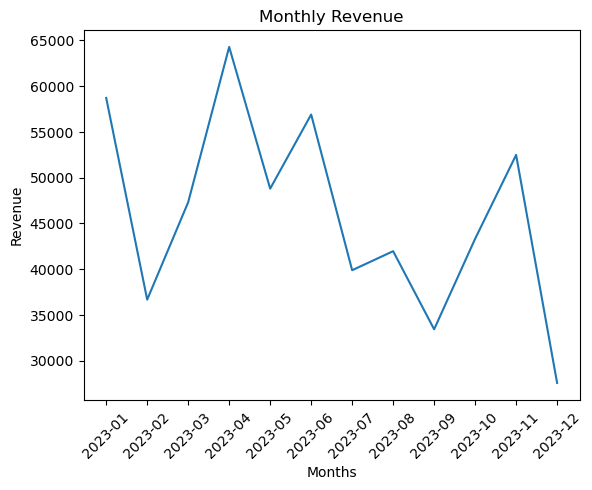

In [50]:
fig, ax = plt.subplots()

x = monthly_revenue['month']
y = monthly_revenue['revenue']

plt.plot(x,y)

plt.title('Monthly Revenue')
plt.xlabel('Months')
plt.ylabel('Revenue')

plt.xticks(rotation = 45)
plt.show();

### Insights

In [51]:
highest_month = monthly_revenue.loc[monthly_revenue['revenue'].idxmax()]
lowest_month = monthly_revenue.loc[monthly_revenue['revenue'].idxmin()]
average_revenue = monthly_revenue['revenue'].mean()
highest_percent = (highest_month['revenue'] - average_revenue) / monthly_revenue['revenue'].mean() * 100
lowest_percent = abs((lowest_month['revenue'] - average_revenue) / monthly_revenue['revenue'].mean() * 100)

In [52]:
print(f'highest revenue month : {highest_month['month']} (${highest_month['revenue']:,.2f})')
print(f'lowest revenue month : {lowest_month['month']} (${lowest_month['revenue']:,.2f})')
print(f'average monthly revenue : ${average_revenue:,.2f}')
print(f'{highest_month['month']} is {highest_percent:.1f}% above the average')
print(f'{lowest_month['month']} is {lowest_percent:.1f}% below the average')

highest revenue month : 2023-04 ($64,271.54)
lowest revenue month : 2023-12 ($27,569.71)
average monthly revenue : $45,937.49
2023-04 is 39.9% above the average
2023-12 is 40.0% below the average


Monthly revenue fluctuated throughout 2023, with no sustained upward or downward trend. Revenue peaked in April at `$64k`, approximately 40% above the annual monthly average of `$46k`, while December recorded the lowest monthly revenue at `$27k`, 40% below the average. This variability suggests that seasonal demand, patient volume, treatment mix, or billing cycles may have influenced monthly financial perormance.

These fluctuations suggest that further analysis into branch performance, appointment volume, and treatment mix may help explain the variation observed throughout the year.

---
### Branch Performance

_Are the branches healthy_

The following analysis evaluates the overall operational and financial performance of each branch by examining key performance indicators.

In [53]:
pd.read_sql('''
select hospital_branch
from doctors
group by hospital_branch
order by hospital_branch
''', conn)

,hospital_branch
0,Central Hospital
1,Eastside Clinic
2,Westside Clinic


In [54]:
# which branch generates the most revenue 
hospital_branch_df = pd.read_sql('''
select d.hospital_branch, sum(amount) as total_revenue
from doctors as d
join appointments as a
on d.doctor_id = a.doctor_id
join treatments as t
on a.appointment_id = t.appointment_id
join billing as b 
on t.treatment_id = b.treatment_id
group by d.hospital_branch
order by total_revenue desc
''', conn)

In [55]:
hospital_branch_df.style.format({
    'total_revenue' : "${:,.2f}"
})

,hospital_branch,total_revenue
0,Central Hospital,"$229,039.44"
1,Eastside Clinic,"$162,031.10"
2,Westside Clinic,"$160,179.31"


>Figure 3. Revenue per branch.

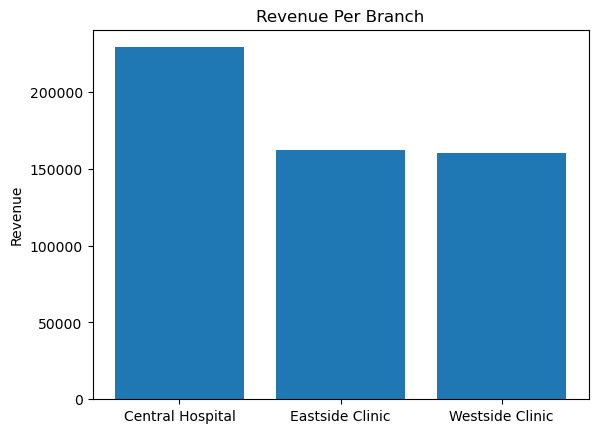

In [56]:
fig, ax = plt.subplots()

x = hospital_branch_df['hospital_branch']
y = hospital_branch_df['total_revenue']

plt.bar(x,y)

plt.title('Revenue Per Branch')
plt.ylabel('Revenue')

plt.show();

In [57]:
# which branch sees the most patients
pd.read_sql('''
select d.hospital_branch, count(distinct(a.patient_id)) as total_patients
from doctors as d
join appointments as a
on d.doctor_id = a.doctor_id
group by d.hospital_branch
order by total_patients desc
''', conn)

,hospital_branch,total_patients
0,Central Hospital,39
1,Westside Clinic,36
2,Eastside Clinic,34


In the above graph, we can see that Central Hospital has the most total patients, with Westside and Eastside Hospital following closely behind. These totals are greater then the total amount of patients treated due to the fact a single patient can visit many hospitals. The success of Central Hospital could be attributed due its location, allowing for a wider reach of people who choose this location, resulting in higher patient count and higher total income.

In [58]:
# which branch has the highest average revenue per patient
branch_revenue = pd.read_sql('''
select d.hospital_branch, sum(b.amount) as total_revenue,
count(distinct(a.patient_id)) as unique_patients,
round(sum(b.amount) * 1.0 / count(distinct(a.patient_id)), 2) as revenue_per_patient
from doctors as d
join appointments as a
on d.doctor_id = a.doctor_id
join treatments as t
on a.appointment_id = t.appointment_id
join billing as b
on t.treatment_id = b.treatment_id
group by d.hospital_branch
order by revenue_per_patient desc
''', conn)

In [59]:
branch_revenue.style.format({
    'total_revenue': "${:,.2f}",
    'revenue_per_patient' : "${:,.2f}",
    'unique_patients' : "{:,}"
})

,hospital_branch,total_revenue,unique_patients,revenue_per_patient
0,Central Hospital,"$229,039.44",39,"$5,872.81"
1,Eastside Clinic,"$162,031.10",34,"$4,765.62"
2,Westside Clinic,"$160,179.31",36,"$4,449.43"


>Figure 4. Average Revenue Per Patient

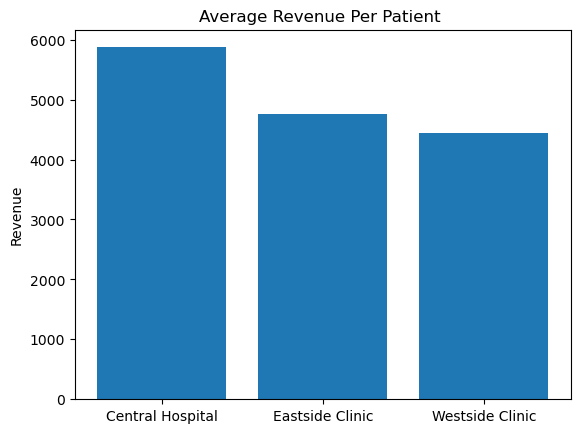

In [60]:
fig, ax = plt.subplots()

x = branch_revenue['hospital_branch']
y = branch_revenue['revenue_per_patient']

plt.bar(x,y)

plt.title('Average Revenue Per Patient ')
plt.ylabel('Revenue')

plt.show();

As seen in Figure 4, Central Hospital also has the highest revenue per patient which corrisponds to having the most patients throughout the year, as well as implying that potentially Central Hospital also offers higher costing treatments and services. 

In [61]:
# branch growth over the year
branch_trends = pd.read_sql('''
select d.hospital_branch, strftime('%m', b.bill_date) as month_number,
strftime('%m', b.bill_date) ||"-"||
case strftime('%m', b.bill_date)
    when '01' then 'jan'
    when '02' then 'Feb'
    when '03' then 'Mar'
    when '04' then 'Apr'
    when '05' then 'May'
    when '06' then 'Jun'
    when '07' then 'Jul'
    when '08' then 'Aug' 
    when '09' then 'Sept'
    when '10' then 'Oct'
    when '11' then 'Nov'
    when '12' then 'Dec'
end as month,
sum(amount) as total_revenue
from doctors as d
join appointments as a
on d.doctor_id = a.doctor_id
join treatments as t
on a.appointment_id = t.appointment_id
join billing as b
on t.treatment_id = b.treatment_id
group by d.hospital_branch,
month_number
order by month_number,
d.hospital_branch
''', conn)

In [62]:
branch_trends.head()

,hospital_branch,month_number,month,total_revenue
0,Central Hospital,01,01-jan,20436.79
1,Eastside Clinic,01,01-jan,15589.82
2,Westside Clinic,01,01-jan,22674.62
3,Central Hospital,02,02-Feb,21989.85
4,Eastside Clinic,02,02-Feb,3728.24


>Figure 5. Monthly Revenue by Hospital Branch

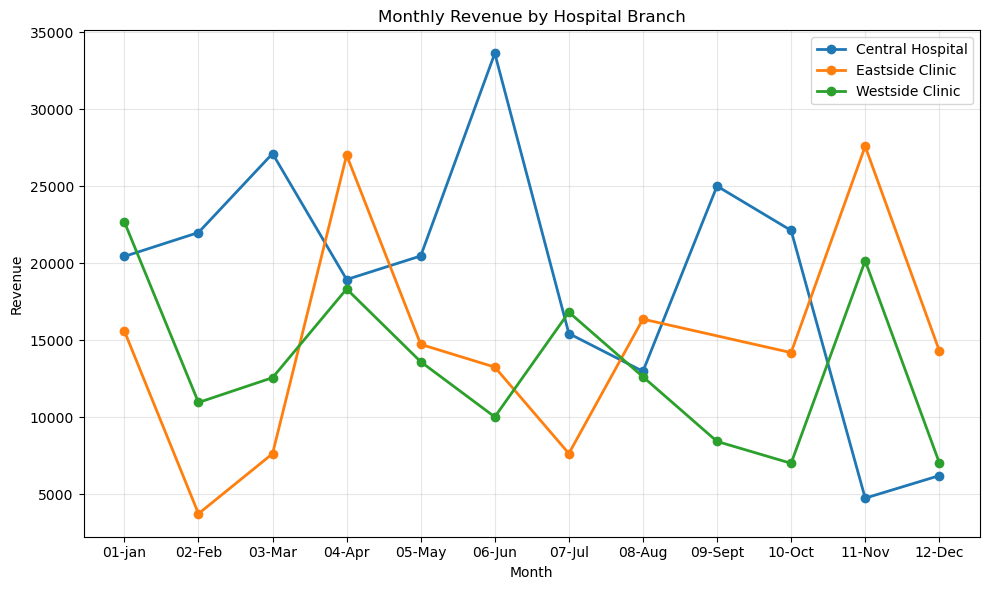

In [63]:
plt.figure(figsize=(10,6))

for branch in branch_trends["hospital_branch"].unique():

    df = branch_trends[
        branch_trends["hospital_branch"] == branch
    ]

    plt.plot(
        df["month"],
        df["total_revenue"],
        marker="o",
        linewidth=2,
        label=branch
    )

plt.title("Monthly Revenue by Hospital Branch")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show();

This plot also shows the same pattern as Figure 2, with a fluctuating revenue resulting in no upward or downward trend.

- Central Hospital
    - highest earner in February, March, May, June and September - 5 months of the year
    - June had the highest revenue, sitting around `$33K`
    - sharp drop in July 
    - significant decline is from October to November, from roughly `$22K` to a little under `$5K`
    - Novemebr and December are the low points 
- Eeastside Clinic 
    - highest earner in April, August, November and December - 4 months of the year
    - lowest start of the year at `$16K`
    - hits the lowest of all locations thoughout the year in Feruary at `$3K`
    - sharp rise in April up to `$27K`
    - sustained drop from april to July, reaching `$7K`
    - slight improvement in august with a small drop to October
    - highest point reaching roughly `$27.5K`
- Westside Clinic
    - highest earner in January, and July - 2 months of the year
    - started the highest of the year at `$23K`
    - steep drop in february
    - slow rise in March and sharp increase to April
    - slow decrease from Arpil to July
    - average revenue from August to October
    - sharp increase again in November to `$27K`, followed by a sharp fall in December

June and November and the 2 months needing furthur investigation. In June, Central hospital hit its peak, well above the clininc locations, as well was the only location with an increase that month. In November, the revenue was the opposite, with Westside and Eastside clinic both having similar peaks, while Central Hospital dipped to their lowest. These trends could be due to appointment volume, treatment mix, billing activity and cycles, or a mixture of it all.

In [64]:
# appointment volume per branch
app_vol = pd.read_sql('''
select hospital_branch, count(appointment_id) as appointment_volume
from doctors as d 
join appointments as a 
on d.doctor_id = a.doctor_id
group by hospital_branch
order by hospital_branch
''', conn)
app_vol

,hospital_branch,appointment_volume
0,Central Hospital,84
1,Eastside Clinic,62
2,Westside Clinic,54


>Figure 6. Branch Appointment Volume

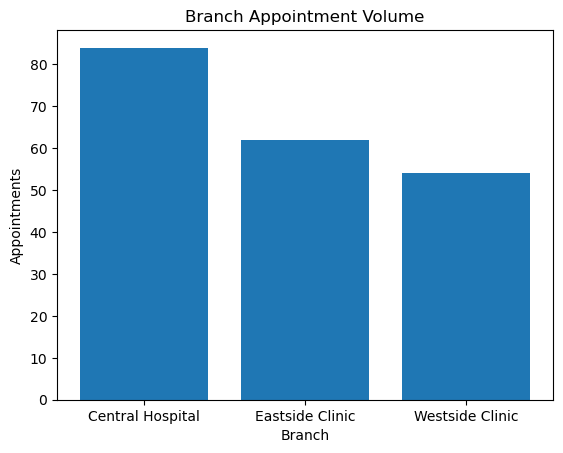

In [65]:
fig, ax = plt.subplots()

x = app_vol['hospital_branch']
y = app_vol['appointment_volume']

plt.bar(x,y)

plt.title('Branch Appointment Volume')
plt.xlabel('Branch')
plt.ylabel('Appointments')

plt.show();

Central Hospital, continuing the shown trends, is once again the top performer. This may be a result of geographic location, provider availability, patient demand or other operational factors. 

### Operations
_Are we using our resouces efficiently_

The following analysis evaluates the overall operational effectivenes of our branches

In [66]:
# what doctors schedule the most patients

doc_sch = pd.read_sql('''
select d.doctor_id, first_name, last_name, hospital_branch, count(a.appointment_id) as total_scheduled_appointments
from doctors as d
join appointments as a
on d.doctor_id = a.doctor_id
group by d.doctor_id, first_name, last_name
order by total_scheduled_appointments desc
''', conn)

In [67]:
# this abbreviation column is being added so in the plot we can quickly see what hospital they work at

abb = {'Central Hospital' : 'CH',
      'Eastside Clinic': 'EC',
      'Westside Clinic': 'WC'}

doc_sch['hospital_abbreviation'] = doc_sch['hospital_branch'].map(abb)

In [68]:
# this full name column is being added so in the plot we can distinguish dcotors

doc_sch['doctor_full_name'] = (doc_sch['first_name'] + 
                               " " +
                              doc_sch['last_name'] + 
                               " " +
                              "(" + 
                              doc_sch['doctor_id'] + 
                               " " +
                              doc_sch['hospital_abbreviation'] + 
                              ")")

In [69]:
doc_sch

,doctor_id,first_name,last_name,hospital_branch,total_scheduled_appointments,hospital_abbreviation,doctor_full_name
0,D005,Sarah,Taylor,Central Hospital,29,CH,Sarah Taylor (D005 CH)
1,D001,David,Taylor,Westside Clinic,25,WC,David Taylor (D001 WC)
2,D006,Alex,Davis,Central Hospital,24,CH,Alex Davis (D006 CH)
3,D003,Jane,Smith,Eastside Clinic,22,EC,Jane Smith (D003 EC)
4,D002,Jane,Davis,Eastside Clinic,21,EC,Jane Davis (D002 EC)
5,D010,Linda,Wilson,Eastside Clinic,19,EC,Linda Wilson (D010 EC)
6,D009,Sarah,Smith,Central Hospital,17,CH,Sarah Smith (D009 CH)
7,D008,Linda,Brown,Westside Clinic,16,WC,Linda Brown (D008 WC)
8,D004,David,Jones,Central Hospital,14,CH,David Jones (D004 CH)
9,D007,Robert,Davis,Westside Clinic,13,WC,Robert Davis (D007 WC)


>Figure 7. Scheduled Appointments by Doctor

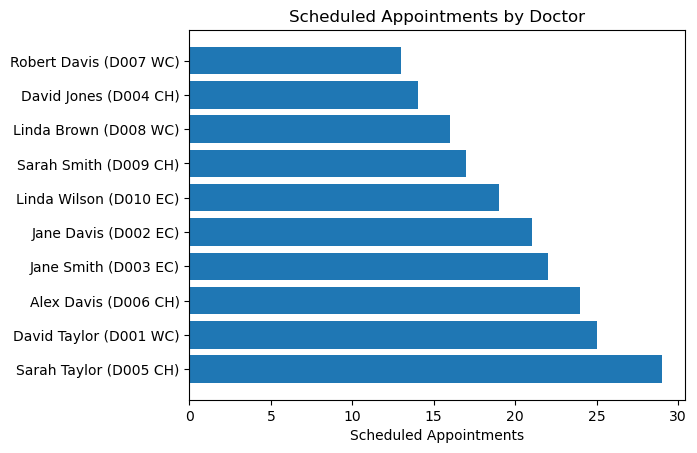

In [70]:
fig, ax = plt.subplots()

y = doc_sch['total_scheduled_appointments']
x = doc_sch['doctor_full_name']

plt.title('Scheduled Appointments by Doctor')
plt.xlabel('Scheduled Appointments')

plt.barh(x,y)
plt.show();

Using this plot, we can see that Sarah Taylor at Central Hospital has the highest amount of scheduled appointments in 2023, followed by David Taylor at Westside and Alex Davis at Central agian. Next we will create a graph that shows completed appointments.

In [71]:
# what doctors complete the most appointments

doc_comp = pd.read_sql('''
select d.doctor_id, first_name, last_name, hospital_branch, count(a.appointment_id) as total_completed_appointments
from doctors as d
join appointments as a
on d.doctor_id = a.doctor_id
where status = 'Completed'
group by d.doctor_id, first_name, last_name
order by total_completed_appointments desc
''', conn)

In [72]:
# this abbreviation column is being added so in the plot we can quickly see what hospital they work at

abb = {'Central Hospital' : 'CH',
      'Eastside Clinic': 'EC',
      'Westside Clinic': 'WC'}

doc_comp['hospital_abbreviation'] = doc_comp['hospital_branch'].map(abb)

In [73]:
# this full name column is being added so in the plot we can distinguish dcotors

doc_comp['doctor_full_name'] = (doc_comp['first_name'] + 
                               " " +
                              doc_comp['last_name'] + 
                               " " +
                              "(" + 
                              doc_comp['doctor_id'] +
                                " " + 
                              doc_comp['hospital_abbreviation'] + 
                              ")")

In [74]:
doc_comp

,doctor_id,first_name,last_name,hospital_branch,total_completed_appointments,hospital_abbreviation,doctor_full_name
0,D001,David,Taylor,Westside Clinic,6,WC,David Taylor (D001 WC)
1,D003,Jane,Smith,Eastside Clinic,6,EC,Jane Smith (D003 EC)
2,D002,Jane,Davis,Eastside Clinic,5,EC,Jane Davis (D002 EC)
3,D006,Alex,Davis,Central Hospital,5,CH,Alex Davis (D006 CH)
4,D007,Robert,Davis,Westside Clinic,5,WC,Robert Davis (D007 WC)
5,D010,Linda,Wilson,Eastside Clinic,5,EC,Linda Wilson (D010 EC)
6,D005,Sarah,Taylor,Central Hospital,4,CH,Sarah Taylor (D005 CH)
7,D008,Linda,Brown,Westside Clinic,4,WC,Linda Brown (D008 WC)
8,D004,David,Jones,Central Hospital,3,CH,David Jones (D004 CH)
9,D009,Sarah,Smith,Central Hospital,3,CH,Sarah Smith (D009 CH)


>Figure 8. Completed Appointments by Doctor

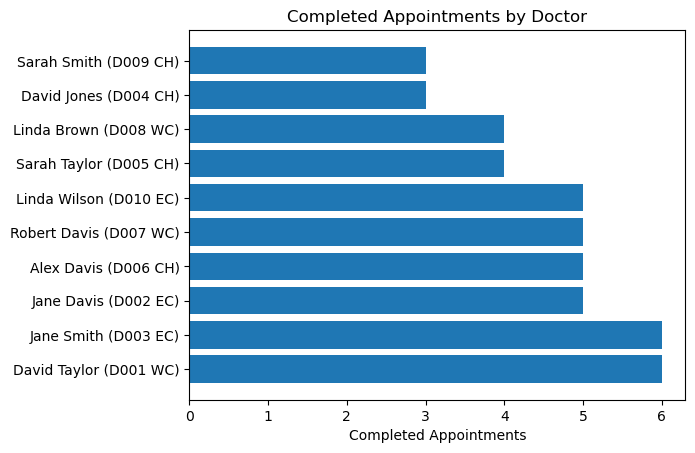

In [75]:
fig, ax = plt.subplots()

x = doc_comp['doctor_full_name']
y = doc_comp['total_completed_appointments']

plt.title('Completed Appointments by Doctor')
plt.xlabel('Completed Appointments')

plt.barh(x,y)
plt.show();

Figure 8 shows that we have a fairly evenly distributed appointment volume accross the staff, with David Taylor and Jane Smith at the top with 6 completed appointments, and Sarah Smith and David Jones at the bottom with 3.

In [76]:
comp_rate = pd.read_sql('''
select status, count(*) as total_appointments, round(count(*) * 100 / (select count(*) from appointments), 2) as percentage
from appointments
group by status
order by total_appointments desc
''', conn)

comp_rate

,status,total_appointments,percentage
0,No-show,52,26.0
1,Scheduled,51,25.0
2,Cancelled,51,25.0
3,Completed,46,23.0


In this plot we can see we have a farily even distribution of status types for appointments. Of course, completed is the status we want, so furthur investigation may be required to see why completed appointments are as common as the rest.

In [77]:
treat_count = pd.read_sql('''
select treatment_type, count(treatment_type) as count
from treatments
group by treatment_type
order by count desc
''', conn)

treat_count

,treatment_type,count
0,Chemotherapy,49
1,X-Ray,41
2,ECG,38
3,Physiotherapy,36
4,MRI,36


>Figure 9. Total amount of each treatment

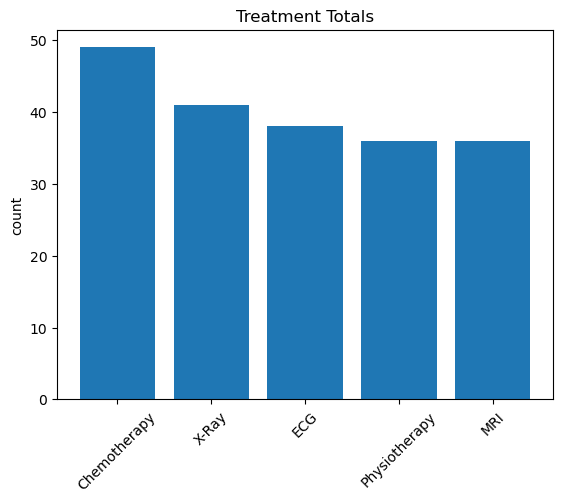

In [78]:
fig, ax = plt.subplots()

x = treat_count['treatment_type']
y = treat_count['count']

plt.xticks(rotation = 45)
plt.title('Treatment Totals')
plt.ylabel('count')

plt.bar(x,y)
plt.show();

Figure 9 shows that chemotherapy is the companies busiest treatment, with 49 scheduled in 2023. MRI and physiotherapy are the least scheduled, sitting at 36 for both. 

### FinancialPerformance
_where is the money coming from_

In [79]:
rev_df = pd.read_sql('''
select treatment_type, round(sum(amount)) as total_revenue
from treatments as t
join appointments as a
on t.appointment_id = a.appointment_id
join billing as b
on t.treatment_id = b.treatment_id
where payment_status = 'Paid'
group by treatment_type
order by total_revenue desc
''', conn)

rev_df

,treatment_type,total_revenue
0,X-Ray,47979.0
1,MRI,43064.0
2,Chemotherapy,32607.0
3,Physiotherapy,32251.0
4,ECG,17523.0


>Figure 10. Total Revenue Per Patient

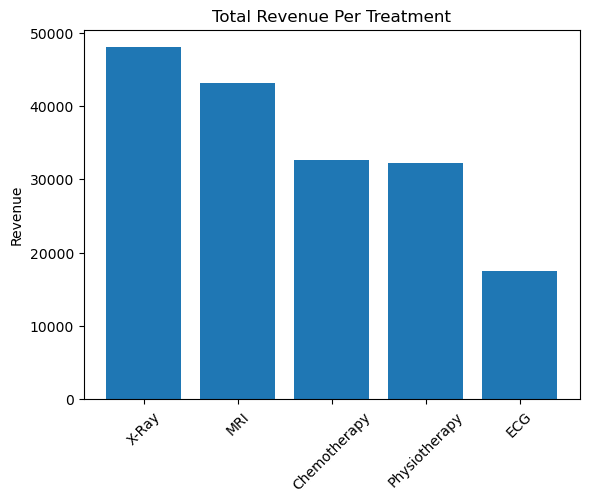

In [80]:
fig, ax = plt.subplots()

x = rev_df['treatment_type']
y = rev_df['total_revenue']

plt.bar(x,y)

plt.xticks(rotation = 45)
plt.title('Total Revenue Per Treatment')
plt.ylabel('Revenue')

plt.show();

Figure 10 shows X-Ray generating the most revenue at `$48K`, followed closely by MRI at `$43K`. Chemotherapy and ECG both drop moderatly, sitting at `$32k` each. ECG is the lowes revenue generator, sitting at `$18K`. This plot goes to show that the most popular treatments aren't always the top revenue generators, possibly due to cost per treamtent as well as insurance billing.

In [81]:
t_cost = pd.read_sql('''
select treatment_type, cost
from treatments
group by treatment_type
order by cost desc
''', conn)

t_cost

,treatment_type,cost
0,MRI,4158.44
1,Chemotherapy,3941.97
2,Physiotherapy,3413.64
3,X-Ray,1882.80
4,ECG,582.05


>Figure 11. Cost Per Treatment

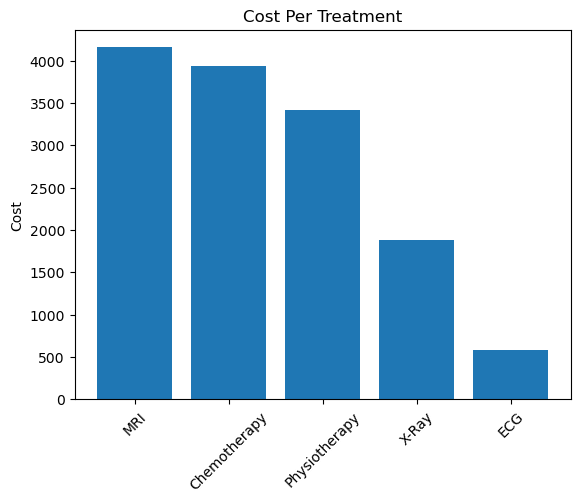

In [82]:
fig, ax = plt.subplots()

x = t_cost['treatment_type']
y = t_cost['cost']

plt.bar(x,y)

plt.xticks(rotation = 45)
plt.title('Cost Per Treatment')
plt.ylabel('Cost')

plt.show();

In [83]:
branch_revenue = pd.read_sql('''
select hospital_branch, sum(amount) as total_revenue
from doctors as d
join appointments as a 
on d.doctor_id = a.doctor_id
join treatments as t 
on a.appointment_id = t.appointment_id 
join billing as b
on t.treatment_id = b.treatment_id
where payment_status = 'Paid'
group by hospital_branch
order by total_revenue desc
''', conn)

branch_revenue

,hospital_branch,total_revenue
0,Central Hospital,86460.11
1,Eastside Clinic,54397.45
2,Westside Clinic,32567.34


>Figure 12. Revenue Per Branch

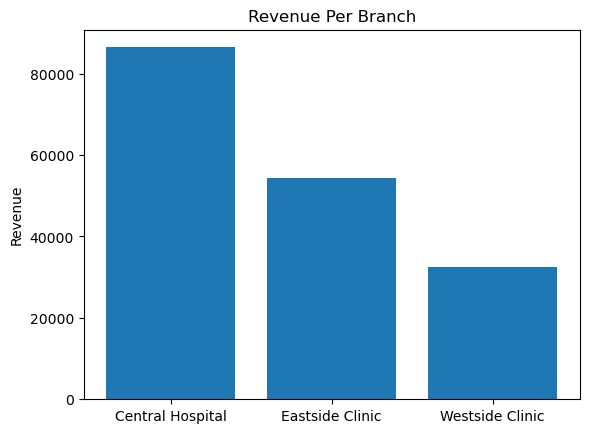

In [84]:
fig, ax = plt.subplots()

x = branch_revenue['hospital_branch']
y = branch_revenue['total_revenue']

plt.bar(x,y)

plt.title('Revenue Per Branch')
plt.ylabel('Revenue')

plt.show();

Once again, we see a trend of central hospital in the lead for revenue.

In [85]:
pd.read_sql('''
select avg(amount) as average_bill_amount
from billing
''', conn)

,average_bill_amount
0,2756.24925


In [86]:
ins_revenue = pd.read_sql('''
select insurance_provider, sum(amount) as revenue
from patients as p
join billing as b
on p.patient_id = b.patient_id
where payment_status = 'Paid'
group by insurance_provider
order by revenue desc
''', conn)

ins_revenue

,insurance_provider,revenue
0,MedCare Plus,81109.48
1,WellnessCorp,45882.28
2,PulseSecure,38486.63
3,HealthIndia,7946.51


>Figure 13. Revenue By Insurance

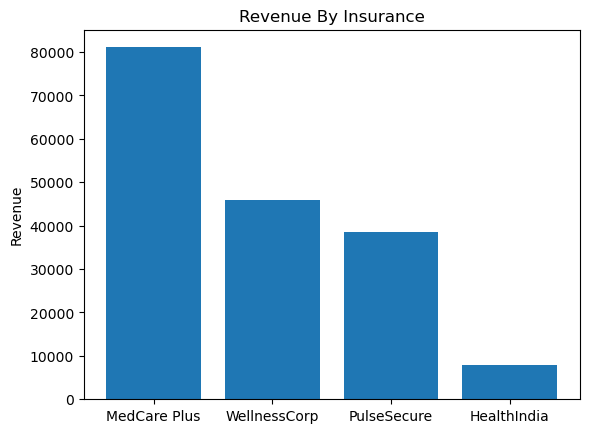

In [87]:
fig, ax = plt.subplots()

x = ins_revenue['insurance_provider']
y = ins_revenue['revenue']

plt.bar(x,y)

plt.title('Revenue By Insurance')
plt.ylabel('Revenue')

plt.show();

Figure 13 shows that MedCare Plus is by far the biggest contributor to revenue, sitting at `$81K`, followd by steep drop offs for each other insurance, with WellnessCorp at `$46K`, PulseSecure at `$38K` and HealthIndia, the lowest, at `$8K`.